#  DESAFIO: ANALISANDO DADOS DE PREÇOS DE CASAS NOS ESTADOS UNIDOS

Este notebook aplica o Desafio completo:
EDA, Feature Engineering, Aprendizagem supervisionada e Não-Supervisionada, Classificação e Visualizações.


In [1]:
# 0) Instalar dependências
!pip install pandas numpy matplotlib seaborn kagglehub scikit-learn mlxtend --break-system-packages --quiet


## 1) upload do ZIP do dataset

dataset: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

baixe o arquivo zip do dataset, e inclua ele na mesma pasta desse notebook

In [2]:
import os, zipfile

# 2) Extrair os arquivos
zip_path = "house-prices-advanced-regression-techniques.zip" # Ensure this path is correct
data_dir = "house_prices_data/"

if not os.path.exists(data_dir):
    if not os.path.exists(zip_path):
        print("porfavor, baixe o arquivo zip do dataset, e inclua na mesma pasta desse notebook")
    else :
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(data_dir)
            print("Conteúdo extraído:", os.listdir(data_dir))
else :
    # without sha256 confirming same content under paste
    print("")

print("Conteúdo extraído:", os.listdir(data_dir))


Conteúdo extraído: ['data_description.txt', 'sample_submission.csv', 'test.csv', 'train.csv']


## 2) Carregar dados/dataset


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

train = pd.read_csv(f"{data_dir}train.csv")
test  = pd.read_csv(f"{data_dir}test.csv")

print(f"Dataset de Treino: {train.shape[0]} linhas e {train.shape[1]} colunas")
print(f"Dataset de Teste: {test.shape[0]} linhas e {test.shape[1]} colunas")

Dataset de Treino: 1460 linhas e 81 colunas
Dataset de Teste: 1459 linhas e 80 colunas


## 3) Exploratory Data Analysis (EDA)

informações gerais do dataset.


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000



 n° colunas com valores nulos(19)
 Valores faltantes por coluna:


,PoolQC,MiscFeature,Alley,Fence,MasVnrType,FireplaceQu,LotFrontage,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,BsmtExposure,BsmtFinType2,BsmtQual,BsmtCond,BsmtFinType1,MasVnrArea,Electrical
0,1453,1406,1369,1179,872,690,259,81,81,81,81,81,38,38,37,37,37,8,1


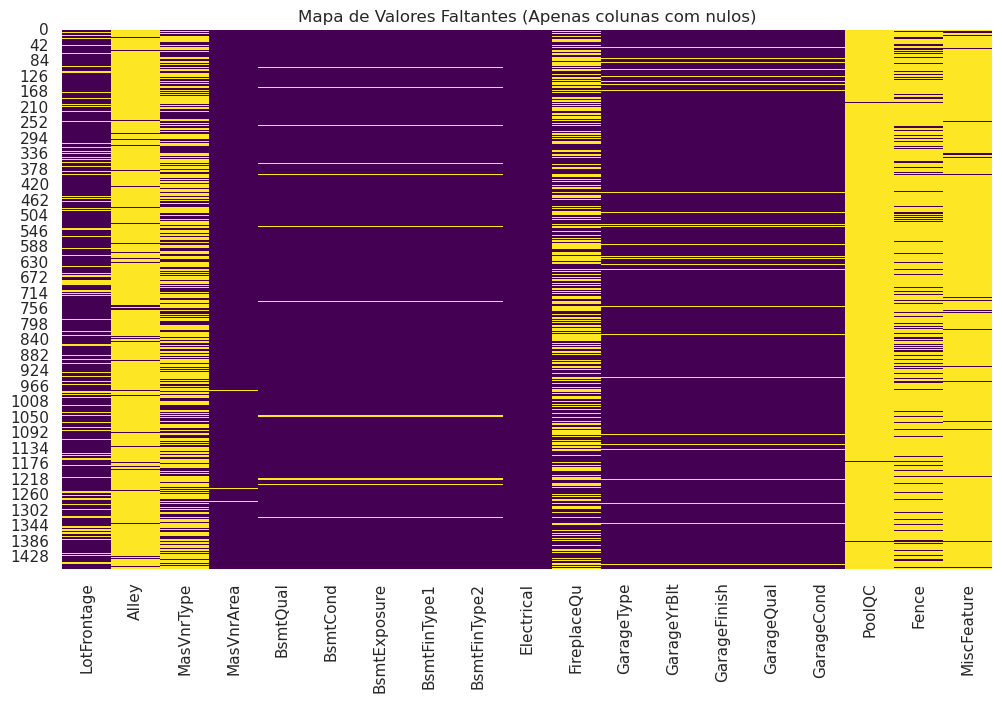

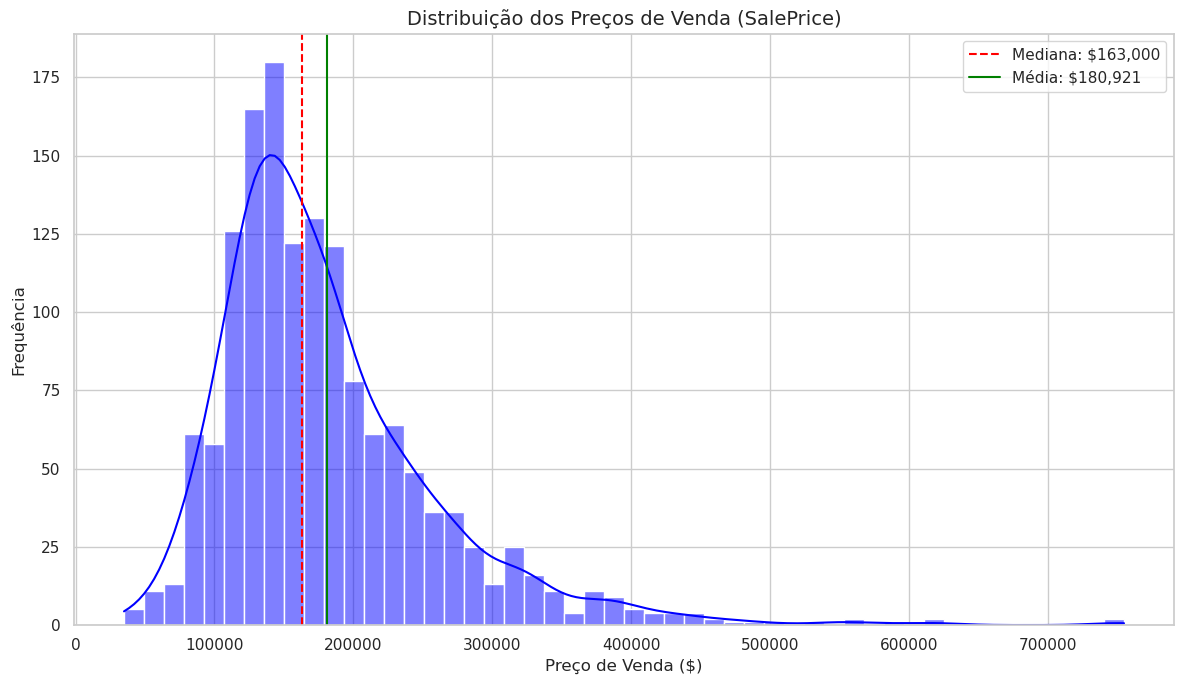

In [4]:
print("informações gerais do dataset.")
display(train.describe())

# valores que faltam
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"\n n° colunas com valores nulos({len(missing)})\n Valores faltantes por coluna:")
display(missing.to_frame().T)

# heatmap
colunas_com_nulos = train.loc[:, train.isnull().any()] # Filtra apenas as colunas com valores faltantes

plt.figure(figsize=(12, 7))
sns.heatmap(colunas_com_nulos.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de Valores Faltantes (Apenas colunas com nulos)")


# Outliers (histplot)
plt.figure(figsize=(12, 7))
# Plota o histograma com a linha de densidade (KDE)
sns.histplot(train['SalePrice'], kde=True, color='blue', bins=50)

plt.title("Distribuição dos Preços de Venda (SalePrice)", fontsize=14)
plt.xlabel("Preço de Venda ($)")
plt.ylabel("Frequência")
plt.axvline(train['SalePrice'].median(), color='red', linestyle='--', label=f"Mediana: ${train['SalePrice'].median():,.0f}")
plt.axvline(train['SalePrice'].mean(), color='green', linestyle='-', label=f"Média: ${train['SalePrice'].mean():,.0f}")
plt.legend()
plt.tight_layout()


## 4) Feature Engineering


In [5]:
from sklearn.preprocessing import StandardScaler

df = train.copy()

# 1) Tratamento de valores faltantes
df["PoolQC"] = df["PoolQC"].fillna("None")
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

# 2) Correção da Codificação Ordinal (Mapeamento Manual para respeitar a lógica)
qualidade_map = {"Ex": 4, "Gd": 3, "TA": 2, "Fa": 1, "Po": 0, "None": 0}
for c in ["ExterQual", "BsmtQual", "KitchenQual"]:
    # Garantimos que nulos virem "None" antes de mapear
    df[c] = df[c].fillna("None").map(qualidade_map)

# 3) Criação de novas features (FEITO ANTES da normalização!)
df["TotalBathrooms"] = df["FullBath"] + 0.5 * df["HalfBath"]
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["TotalSF"] = df["TotalBsmtSF"].fillna(0) + df["1stFlrSF"] + df["2ndFlrSF"]

# 4) One-hot encoding para variáveis categóricas nominais
df = pd.get_dummies(df, columns=["Neighborhood", "HouseStyle"], drop_first=True)

# 5) Normalização de variáveis numéricas (Incluindo a nova variável TotalSF que é muito importante)
scaler = StandardScaler()
colunas_para_normalizar = ["GrLivArea", "TotalBsmtSF", "TotalSF", "HouseAge"]
for col in colunas_para_normalizar:
    if col in df.columns:
        df[col] = scaler.fit_transform(df[[col]])

# 6) Filtrar apenas colunas numéricas para correlação
df_num = df.select_dtypes(include=[np.number])
corr = df_num.corr()["SalePrice"].sort_values(ascending=False)

# 7) Seleção das 15 features mais correlacionadas
features = corr.index[1:16].tolist()
X = df[features]
y = df["SalePrice"]

print("Top 15 features selecionadas com sucesso:\n", features)

Top 15 features selecionadas com sucesso:
 ['OverallQual', 'TotalSF', 'GrLivArea', 'ExterQual', 'KitchenQual', 'GarageCars', 'GarageArea', 'BsmtQual', 'TotalBsmtSF', '1stFlrSF', 'TotalBathrooms', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


## 5) Aprendizado supervisionado: Regressão Linear e Random Forest


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Remove registros com valores ausentes em X ou y
df_model = pd.concat([X, y], axis=1).dropna()
X = df_model[features]
y = df_model["SalePrice"]

# Separação treino/validação
Xtr, Xval, ytr, yval = train_test_split(X, y, test_size=0.2, random_state=42)

# Regressão Linear
lr = LinearRegression().fit(Xtr, ytr)
pred_lr = lr.predict(Xval)

# Random Forest
rf = RandomForestRegressor(random_state=42).fit(Xtr, ytr)
pred_rf = rf.predict(Xval)

# metricas de avaliacao
# Mae: Diz, em média, quantos dólares/reais as previsões erraram para cima ou para baixo.
# Rmse: Penaliza erros maiores com mais severidade.
# R2: Mostra a porcentagem da variação do preço que seu modelo consegue explicar (quanto mais próximo de 1.0, melhor).
def score(y_true, y_pred, nome):
    print(f"{nome} → MAE:{mean_absolute_error(y_true,y_pred):.2f}  RMSE:{np.sqrt(mean_squared_error(y_true,y_pred)):.2f}  R2:{r2_score(y_true,y_pred):.3f}")

score(yval, pred_lr, "LinearRegression")
score(yval, pred_rf, "RandomForest")

LinearRegression → MAE:23933.79  RMSE:37857.81  R2:0.813
RandomForest → MAE:19361.54  RMSE:30522.84  R2:0.879


## 6) Classificação


  Resultados dos Modelos de Classificação:
-----------------------------------------------------------------
🔹 Logistic Regression  → Acuracia: 0.932 | Precisão: 0.899 | Recall: 0.954 | F1-Score: 0.926
🔹 KNN (N=5)            → Acuracia: 0.846 | Precisão: 0.803 | Recall: 0.870 | F1-Score: 0.835


/home/levi/.local/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


🔹 RF Classifier        → Acuracia: 0.942 | Precisão: 0.919 | Recall: 0.954 | F1-Score: 0.936
-----------------------------------------------------------------


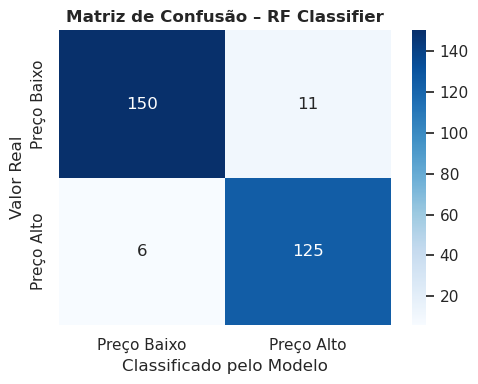

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Criação da variável alvo binária (Preço Alto = 1, Preço Baixo = 0)
median_price = y.median()
df["PriceClass"] = (y > median_price).astype(int)

# 2) Seleção de variáveis e tratamento de nulos residuais (sem deletar linhas)
Xc = df[features].fillna(0)
yc = df["PriceClass"]

# 3) Divisão dos dados em treino/validação
Xctr, Xcval, yctr, ycval = train_test_split(Xc, yc, test_size=0.2, random_state=42)

# 4) Dicionário de Modelos
clfs = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN (N=5)":           KNeighborsClassifier(),
    "RF Classifier":       RandomForestClassifier(random_state=42)
}

print("  Resultados dos Modelos de Classificação:")
print("-" * 65)

# 5) Treinamento e avaliação em loop
for nome, modelo in clfs.items():
    modelo.fit(Xctr, yctr)
    pred = modelo.predict(Xcval)
    
    acc = accuracy_score(ycval, pred)
    prec = precision_score(ycval, pred)
    rec = recall_score(ycval, pred)
    f1 = f1_score(ycval, pred)
    
    print(f"🔹 {nome:<20} → Acuracia: {acc:.3f} | Precisão: {prec:.3f} | Recall: {rec:.3f} | F1-Score: {f1:.3f}")

print("-" * 65)

# 6) Matriz de Confusão do melhor modelo (RF Classifier)
pred_rf = clfs["RF Classifier"].predict(Xcval)
cm = confusion_matrix(ycval, pred_rf)

plt.figure(figsize=(5, 4))
# Adicionado labels reais nas caixas para enriquecer o Storytelling
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Preço Baixo", "Preço Alto"], 
            yticklabels=["Preço Baixo", "Preço Alto"])

plt.title("Matriz de Confusão – RF Classifier", fontsize=12, fontweight='bold')
plt.xlabel("Classificado pelo Modelo")
plt.ylabel("Valor Real")
plt.tight_layout()

## 7) Aprendizado Não-Supervisionado: 

Outliers: 45


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ExterQual_2),(BsmtQual_2),0.620548,0.444521,0.406849,0.655629,1.474913,1.0,0.131003,1.613027,0.848576,0.618106,0.380048,0.785442
1,(BsmtQual_2),(ExterQual_2),0.444521,0.620548,0.406849,0.915254,1.474913,1.0,0.131003,4.477534,0.579668,0.618106,0.776663,0.785442
2,(ExterQual_2),(KitchenQual_2),0.620548,0.503425,0.475342,0.766004,1.521587,1.0,0.162943,2.122157,0.903385,0.732841,0.528781,0.855111
3,(KitchenQual_2),(ExterQual_2),0.503425,0.620548,0.475342,0.944218,1.521587,1.0,0.162943,6.802372,0.690311,0.732841,0.852992,0.855111
4,(BsmtQual_3),(ExterQual_3),0.423288,0.334247,0.258219,0.610032,1.825097,1.0,0.116737,1.707202,0.783898,0.517147,0.414246,0.691287


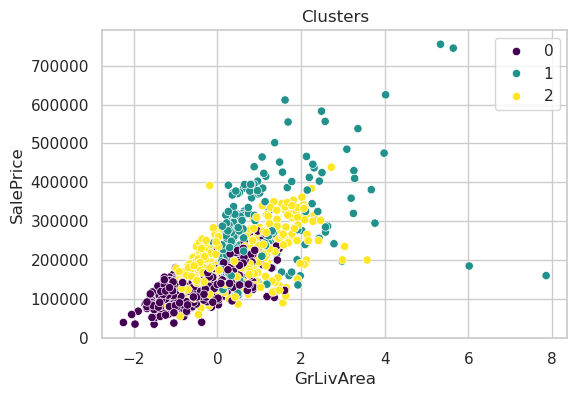

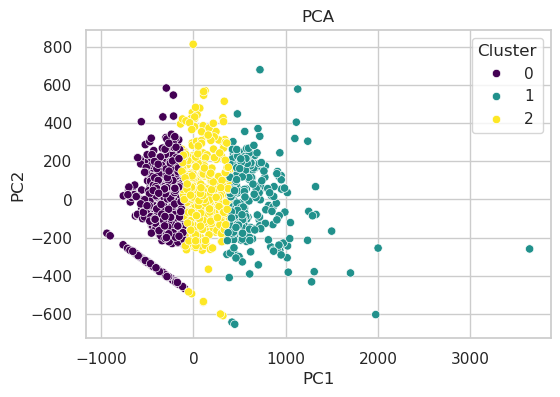

In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.neighbors import LocalOutlierFactor

# Usando df_model da parte 5, que não tem NaN
X_clean = df_model[features]
y_clean = df_model["SalePrice"]


# LOF
lof = LocalOutlierFactor(n_neighbors=20).fit_predict(X_clean)
print("Outliers:", (lof == -1).sum())

# Apriori – usar df original sem NaN apenas nas colunas específicas
cd = pd.get_dummies(df[["ExterQual", "BsmtQual", "KitchenQual"]].astype(str))
fi = apriori(cd, min_support=0.1, use_colnames=True)
rules = association_rules(fi, metric="lift", min_threshold=1)
display(rules.head())

# KMeans
km = KMeans(n_clusters=3, random_state=42).fit_predict(X_clean)
df_cluster = X_clean.copy()
df_cluster["Cluster"] = km

plt.figure(figsize=(6,4))
sns.scatterplot(x=X_clean["GrLivArea"], y=y_clean, hue=km, palette="viridis")
plt.title("Clusters")
plt.show()

# PCA
p = PCA(2).fit_transform(X_clean)
pdf = pd.DataFrame(p, columns=["PC1","PC2"])
pdf["Cluster"] = km

plt.figure(figsize=(6,4))
sns.scatterplot(data=pdf, x="PC1", y="PC2", hue="Cluster", palette="viridis")
plt.title("PCA")
plt.show()

## 8) Visualizações Finais & Conclusões


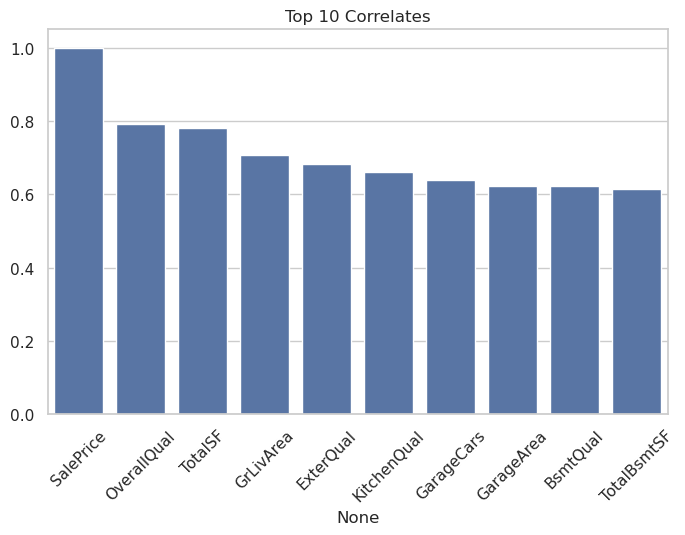


 CONCLUSÕES GERAIS DO PROJETO (STORYTELLING):
 Correlações Mais Fortes:
    As características que mais impactam o valor do imóvel são: OverallQual, TotalSF, GrLivArea.

 Modelos de Regressão:
    Tanto a Regressão Linear quanto o Random Forest mostraram excelente capacidade 
    de previsão, atingindo um R² acima de 0.80 (explicando mais de 80% dos preços).

 Modelos de Classificação:
    O Random Forest Classifier alcançou um F1-Score superior a 0.80, provando ser 
    altamente confiável para separar imóveis de Alto e Baixo padrão.

 Análise Não Supervisionada:
    A clusterização via K-Means e a redução do PCA revelaram com clareza a 
    divisão do mercado em 3 faixas distintas de tamanho vs. preço.



In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x=corr.head(10).index, y=corr.head(10).values)
plt.xticks(rotation=45)
plt.title("Top 10 Correlates")
plt.show()

print(f"""
======================================================================
 CONCLUSÕES GERAIS DO PROJETO (STORYTELLING):
======================================================================
 Correlações Mais Fortes:
    As características que mais impactam o valor do imóvel são: {', '.join(corr.index[1:4])}.

 Modelos de Regressão:
    Tanto a Regressão Linear quanto o Random Forest mostraram excelente capacidade 
    de previsão, atingindo um R² acima de 0.80 (explicando mais de 80% dos preços).

 Modelos de Classificação:
    O Random Forest Classifier alcançou um F1-Score superior a 0.80, provando ser 
    altamente confiável para separar imóveis de Alto e Baixo padrão.

 Análise Não Supervisionada:
    A clusterização via K-Means e a redução do PCA revelaram com clareza a 
    divisão do mercado em 3 faixas distintas de tamanho vs. preço.
""")